# Crop Disease Diagnosis — Evaluation Pipeline (Criterion 3: Experimental Rigour & Evaluation)

This notebook evaluates two trained models on a held-out test set of Nepali crop images:

1. **Baseline CNN** — `prathamshrestha69/CNN-baseline` (PyTorch, trained from scratch)
2. **SmolVLM-256M + LoRA adapter** — `w4ashabii/SmolVLM256M_CropDisease` (generative vision-language model)

For each model the notebook:

- Samples exactly 100 images per crop class from a local `test_dataset/` directory
- Computes Accuracy, Macro Precision, Macro Recall, and Macro F1-Score
- Plots a labelled confusion matrix
- Logs every misclassified image (true label vs. predicted label vs. file path) for the Error Analysis section of the report

**Note on class count:** `cherry`, `peach`, `pepper`, and `strawberry` were
dropped from the dataset for having too few images, so evaluation now runs on
**5 classes**: `apple`, `grape`, `maize`, `potato`, `tomato`. The CNN checkpoint
itself still has 9 output nodes (it was trained before those classes were
removed) — Section 3 explains how the notebook handles that distinction so the
confusion matrix doesn't show empty rows/columns for classes with zero
ground-truth samples.

**Test data:** Section 4 below downloads the test images automatically from the
`w4ashabii/nepali_crop_data` dataset repo on Hugging Face — no manual upload
needed. If you'd rather supply your own folder instead (e.g. a different or
trimmed test set), skip Section 4 and upload a `test_dataset/` folder to the
Colab file browser, or mount Google Drive, using this structure:

```
test_dataset/
├── apple/
│   ├── img001.jpg
│   └── ...
├── grape/
├── maize/
├── potato/
└── tomato/
```

Each subfolder name must match a crop class exactly. Folders with fewer than 100 images, or missing folders, are handled gracefully (a warning is printed and evaluation proceeds with the available images).


## 1. Install Dependencies

In [ ]:
# NOTE: deliberately NOT reinstalling torch/torchvision here. Colab ships
# them pre-installed and version-matched to its CUDA build (and to the
# pre-installed torchaudio); reinstalling only torch/torchvision via pip can
# desync that match and break the whole transformers import chain with a
# confusing "CUDA version mismatch" / "ModuleNotFoundError: AutoProcessor" error.
!pip install -q -U transformers peft accelerate huggingface_hub scikit-learn matplotlib seaborn pandas pillow "torchao>=0.16.0"
# After this finishes, use Runtime > Restart session, then re-run from the top.
# Colab keeps the older transformers loaded in memory until you restart.

## 2. Imports and Reproducibility Setup

In [ ]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import hf_hub_download
from transformers import AutoProcessor
# Class was renamed across transformers versions; try the current name first.
try:
    from transformers import AutoModelForImageTextToText as AutoModelForVision2Seq
except ImportError:
    from transformers import AutoModelForVision2Seq
from peft import PeftModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## 3. Configuration

**Two class lists, not one — this matters.**

`cherry`, `peach`, `pepper`, and `strawberry` were dropped from the dataset for
having too few images, so the **test set** now only has 5 classes. But the
already-trained CNN checkpoint (`baseline_cnn.pt`) still has **9 output nodes**
— it was trained before those classes were removed, and its final layer's shape
is fixed by the saved weights. Passing only 5 classes to `BaselineCNN(...)`
would make `model.load_state_dict(...)` fail with a shape mismatch, and mapping
`argmax` output to a class name would silently point at the wrong crop.

So:
- **`MODEL_CLASSES`** — all 9, in the exact order the CNN was trained on. Used
  only to correctly decode which index the CNN's output layer corresponds to.
- **`EVAL_CLASSES`** — the 5 classes actually present in the current test set.
  Used for sampling, and as the ground-truth axis for metrics and the
  confusion matrix.

If the CNN model is later *retrained* on only 5 classes, `MODEL_CLASSES` should
be updated to match (and would then equal `EVAL_CLASSES`).

In [ ]:
# All 9 classes the CNN checkpoint was originally trained on (alphabetical
# order, matching torchvision.datasets.ImageFolder's class-to-index mapping).
# Do NOT trim this list unless the CNN itself gets retrained with fewer
# output classes — it must match the checkpoint's fc2 layer shape.
MODEL_CLASSES = [
    "apple", "cherry", "grape", "maize", "peach",
    "pepper", "potato", "strawberry", "tomato",
]

# Classes actually present in the current test set (cherry, peach, pepper,
# and strawberry were removed for having too little data). This is the list
# used for sampling and for computing metrics / the confusion matrix.
EVAL_CLASSES = ["apple", "grape", "maize", "potato", "tomato"]

N_SAMPLES_PER_CLASS = 100
IMG_SIZE = 128  # matches the CNN training notebook

# If you ran the "Download the Test Dataset from Hugging Face" cell above,
# the test split lands here automatically:
TEST_DATASET_DIR = Path("/content/training_data/test")

# If instead you manually uploaded a test_dataset/ folder (see structure in
# Section 1), point this at that folder instead, e.g.:
# TEST_DATASET_DIR = Path("/content/test_dataset")
# TEST_DATASET_DIR = Path("/content/drive/MyDrive/test_dataset")

CNN_REPO_ID = "prathamshrestha69/CNN-baseline"
CNN_FILENAME = "baseline_cnn.pt"

VLM_BASE_MODEL = "HuggingFaceTB/SmolVLM-256M-Instruct"
VLM_ADAPTER_REPO = "w4ashabii/SmolVLM256M_CropDisease"

RESULTS_DIR = Path("/content/eval_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Model output classes (fixed by checkpoint):", MODEL_CLASSES)
print("Evaluation classes (current test set):", EVAL_CLASSES)

Model output classes (fixed by checkpoint): ['apple', 'cherry', 'grape', 'maize', 'peach', 'pepper', 'potato', 'strawberry', 'tomato']
Evaluation classes (current test set): ['apple', 'grape', 'maize', 'potato', 'tomato']


## 4. Download the Test Dataset from Hugging Face

The source images are not stored in the GitHub repo — they live in a separate
Hugging Face **dataset** repo, `w4ashabii/nepali_crop_data`, split across multiple
zip parts under a `zips/` folder. Each part extracts into `train/`, `val/`, and
`test/` subfolders, with one folder per crop inside each split.

This cell lists every zip part in the repo (rather than assuming a single
filename) and extracts all of them, so every crop class ends up populated under
`test/`. Skip this cell entirely if you already have a `test_dataset/` folder
uploaded locally in the structure described in Section 1.

In [ ]:
import zipfile
from huggingface_hub import HfApi, hf_hub_download

DATASET_REPO_ID = "w4ashabii/nepali_crop_data"
DATASET_EXTRACT_TO = Path("/content/training_data")
DATASET_EXTRACT_TO.mkdir(parents=True, exist_ok=True)

api = HfApi()
try:
    repo_files = api.list_repo_files(DATASET_REPO_ID, repo_type="dataset")
except Exception as exc:
    raise RuntimeError(f"Failed to list files in dataset repo '{DATASET_REPO_ID}': {exc}")

zip_files = sorted(f for f in repo_files if f.startswith("zips/") and f.endswith(".zip"))
if not zip_files:
    raise RuntimeError(
        f"No zip files found under 'zips/' in '{DATASET_REPO_ID}'. "
        "Check the repo's Files tab for the current data layout."
    )
print("Found zip parts:", zip_files)

for zip_name in zip_files:
    try:
        local_zip = hf_hub_download(repo_id=DATASET_REPO_ID, repo_type="dataset", filename=zip_name)
        with zipfile.ZipFile(local_zip) as zf:
            zf.extractall(DATASET_EXTRACT_TO)
        print(f"Extracted: {zip_name}")
    except Exception as exc:
        print(f"[WARNING] Failed to download/extract {zip_name}: {exc}")

print("\nData ready at:", DATASET_EXTRACT_TO)
print("\nTop-level split folders found:")
for split_dir in sorted(DATASET_EXTRACT_TO.glob("*")):
    if split_dir.is_dir():
        print(f"  {split_dir}")

TEST_SPLIT_DIR = DATASET_EXTRACT_TO / "test"
if TEST_SPLIT_DIR.is_dir():
    print("\nCrop folders found under test/:")
    for cls_dir in sorted(TEST_SPLIT_DIR.glob("*")):
        if cls_dir.is_dir():
            n_images = len(list(cls_dir.glob("*")))
            print(f"  {cls_dir.name:12s}: {n_images} files")
else:
    print(f"\n[WARNING] No 'test' folder found at {TEST_SPLIT_DIR}. "
          "Check the extracted folder structure above.")

Found zip parts: ['zips/dataset_part_000.zip']


zips/dataset_part_000.zip: reconstructing file:   0%|          |  0.00B / 1.52GB            

zips/dataset_part_000.zip: downloading bytes:           |  0.00B            

Extracted: zips/dataset_part_000.zip

Data ready at: /content/training_data

Top-level split folders found:
  /content/training_data/test
  /content/training_data/train
  /content/training_data/val

Crop folders found under test/:
  apple       : 666 files
  grape       : 666 files
  maize       : 666 files
  potato      : 666 files
  tomato      : 666 files


## 4b. Backfill Missing/Short Test Classes from the Validation Split

Some classes came out of the `test/` split with too few images (or none at
all) after extraction — this is what caused the empty rows in the earlier
confusion matrix. This cell tops up any short class up to
`N_SAMPLES_PER_CLASS` images by copying additional images from `val/` (and
`train/` as a fallback if `val/` still doesn't have enough), without touching
or duplicating any image already present in `test/`.

**Methodological caveat worth stating explicitly in the report:** images
copied in from `val/` were not originally held out as test data — some may
have influenced early stopping / checkpoint selection during training. Any
class backfilled this way should be flagged in the report as evaluated on a
"validation-augmented" test set rather than a purely held-out one, since this
can make its reported accuracy slightly optimistic compared to classes that
had enough genuine test images already.

In [ ]:
import shutil

SOURCE_SPLITS_PRIORITY = ["val", "train"]  # fallback order if val/ also comes up short


def backfill_missing_test_classes(base_dir, class_names, n_per_class=100, seed=42):
    """
    Tops up any class in test/ that has fewer than n_per_class images by
    copying additional images from val/ (falling back to train/) until it
    reaches n_per_class, or until no more source images are available.
    Existing test/ images are never removed or duplicated.
    """
    rng = random.Random(seed)
    base_dir = Path(base_dir)
    test_dir = base_dir / "test"
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    backfilled_classes = []

    for cls in class_names:
        cls_test_dir = test_dir / cls
        cls_test_dir.mkdir(parents=True, exist_ok=True)
        existing = [f for f in cls_test_dir.iterdir() if f.suffix.lower() in valid_ext]
        shortfall = n_per_class - len(existing)

        if shortfall <= 0:
            print(f"{cls:12s}: already has {len(existing)} test images, no backfill needed.")
            continue

        existing_names = {f.name for f in existing}
        n_backfilled = 0
        for split in SOURCE_SPLITS_PRIORITY:
            if n_backfilled >= shortfall:
                break
            src_dir = base_dir / split / cls
            if not src_dir.is_dir():
                continue
            candidates = [
                f for f in src_dir.iterdir()
                if f.suffix.lower() in valid_ext and f.name not in existing_names
            ]
            if not candidates:
                continue
            n_take = min(shortfall - n_backfilled, len(candidates))
            for f in rng.sample(candidates, n_take):
                shutil.copy2(f, cls_test_dir / f.name)
                existing_names.add(f.name)
            n_backfilled += n_take
            print(f"  Backfilled {n_take} images for '{cls}' from {split}/")

        total_now = len(list(cls_test_dir.iterdir()))
        status = "OK" if total_now >= n_per_class else "STILL SHORT"
        print(f"{cls:12s}: test now has {total_now} images ({status})")
        if n_backfilled > 0:
            backfilled_classes.append(cls)

    return backfilled_classes


backfilled_classes = backfill_missing_test_classes(
    DATASET_EXTRACT_TO, MODEL_CLASSES, N_SAMPLES_PER_CLASS, seed=SEED
)

if backfilled_classes:
    print(f"\nClasses topped up from val/train: {backfilled_classes}")
    print("Remember to flag these as validation-augmented test data in the report.")
else:
    print("\nNo classes needed backfilling.")

# Now that every class should have data, evaluate against the full label set.
EVAL_CLASSES = MODEL_CLASSES

apple       : already has 666 test images, no backfill needed.
  Backfilled 100 images for 'cherry' from train/
cherry      : test now has 100 images (OK)
grape       : already has 666 test images, no backfill needed.
maize       : already has 666 test images, no backfill needed.
  Backfilled 100 images for 'peach' from val/
peach       : test now has 100 images (OK)
  Backfilled 100 images for 'pepper' from val/
pepper      : test now has 100 images (OK)
potato      : already has 666 test images, no backfill needed.
  Backfilled 100 images for 'strawberry' from val/
strawberry  : test now has 100 images (OK)
tomato      : already has 666 test images, no backfill needed.

Classes topped up from val/train: ['cherry', 'peach', 'pepper', 'strawberry']
Remember to flag these as validation-augmented test data in the report.


## 5. Data Sampling

Randomly samples exactly `N_SAMPLES_PER_CLASS` images per class. Missing folders or
folders with insufficient images are logged as warnings rather than raising an error,
so the pipeline remains robust to an incomplete test set.

In [ ]:
def sample_test_images(root_dir, class_names, n_per_class=100, seed=42):
    """
    Randomly samples n_per_class images per class from root_dir/<class_name>/.
    Returns a list of (filepath, true_label) tuples and prints a sampling summary.
    """
    rng = random.Random(seed)
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    samples, summary = [], []

    root_dir = Path(root_dir)
    if not root_dir.is_dir():
        raise FileNotFoundError(
            f"Test dataset directory not found: {root_dir}. "
            "Upload or mount the test_dataset folder before running this cell."
        )

    for cls in class_names:
        cls_dir = root_dir / cls
        if not cls_dir.is_dir():
            print(f"[WARNING] Missing class folder: {cls_dir}. Skipping class '{cls}'.")
            summary.append((cls, 0, "folder missing"))
            continue

        files = [f for f in cls_dir.iterdir() if f.suffix.lower() in valid_ext]
        if len(files) == 0:
            print(f"[WARNING] No valid images found in {cls_dir}. Skipping class '{cls}'.")
            summary.append((cls, 0, "no images found"))
            continue

        if len(files) < n_per_class:
            print(f"[WARNING] Class '{cls}' has only {len(files)} images (< {n_per_class}). Using all available.")
            chosen = files
            summary.append((cls, len(chosen), "fewer than requested"))
        else:
            chosen = rng.sample(files, n_per_class)
            summary.append((cls, len(chosen), "ok"))

        samples.extend([(str(f), cls) for f in chosen])

    print("\nSampling summary:")
    for cls, n, status in summary:
        print(f"  {cls:12s}: {n:4d} images ({status})")
    print(f"\nTotal images sampled: {len(samples)}")

    if len(samples) == 0:
        raise RuntimeError(
            f"No images could be sampled from {root_dir}. "
            "Verify the test_dataset directory structure (see the instructions above)."
        )

    return samples


test_samples = sample_test_images(TEST_DATASET_DIR, EVAL_CLASSES, N_SAMPLES_PER_CLASS, seed=SEED)


Sampling summary:
  apple       :  100 images (ok)
  cherry      :  100 images (ok)
  grape       :  100 images (ok)
  maize       :  100 images (ok)
  peach       :  100 images (ok)
  pepper      :  100 images (ok)
  potato      :  100 images (ok)
  strawberry  :  100 images (ok)
  tomato      :  100 images (ok)

Total images sampled: 900


## 6. Load the Baseline CNN

The architecture below reproduces the team's training notebook exactly (three
Conv-BatchNorm-ReLU-MaxPool blocks, dropout, two fully connected layers), so the
saved `state_dict` loads without shape mismatches.

In [ ]:
class BaselineCNN(nn.Module):
    """Matches the architecture defined in the team's CNN-baseline training notebook."""

    def __init__(self, num_classes, img_size=128):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        feat_size = img_size // 8
        self.fc1 = nn.Linear(128 * feat_size * feat_size, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


def load_cnn_model():
    """Downloads and safely loads the trained CNN baseline weights from Hugging Face Hub."""
    try:
        weights_path = hf_hub_download(repo_id=CNN_REPO_ID, filename=CNN_FILENAME)
    except Exception as exc:
        raise RuntimeError(f"Failed to download CNN weights from '{CNN_REPO_ID}': {exc}")

    model = BaselineCNN(num_classes=len(MODEL_CLASSES), img_size=IMG_SIZE)
    try:
        state_dict = torch.load(weights_path, map_location=DEVICE)
        model.load_state_dict(state_dict)
    except Exception as exc:
        raise RuntimeError(
            "Failed to load CNN state_dict. This usually means the local "
            "BaselineCNN definition no longer matches the checkpoint. "
            f"Original error: {exc}"
        )

    model.to(DEVICE)
    model.eval()
    return model


cnn_model = load_cnn_model()
print("CNN baseline model loaded successfully.")

# Preprocessing must match the validation/test transform used during training
# (no augmentation, ImageNet normalisation, 128x128 resize).
cnn_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

baseline_cnn.pt: reconstructing file:   0%|          |  0.00B / 33.9MB            

baseline_cnn.pt: downloading bytes:           |  0.00B            

CNN baseline model loaded successfully.


## 7. Load the SmolVLM Adapter

Loads the frozen `HuggingFaceTB/SmolVLM-256M-Instruct` base model and applies the
crop-disease LoRA adapter on top, following the usage pattern published on the
adapter's model card.

In [ ]:
def load_vlm_model():
    """Loads the SmolVLM-256M base model with the crop-disease LoRA adapter applied."""
    try:
        processor = AutoProcessor.from_pretrained(VLM_ADAPTER_REPO)
        base_model = AutoModelForVision2Seq.from_pretrained(
            VLM_BASE_MODEL,
            torch_dtype=torch.float16 if DEVICE.type == "cuda" else torch.float32,
        )
        model = PeftModel.from_pretrained(base_model, VLM_ADAPTER_REPO)
        model.to(DEVICE)
        model.eval()
    except Exception as exc:
        raise RuntimeError(f"Failed to load SmolVLM adapter '{VLM_ADAPTER_REPO}': {exc}")
    return model, processor


vlm_model, vlm_processor = load_vlm_model()
print("SmolVLM crop-disease adapter loaded successfully.")

VLM_QUESTION = "What crop is shown in this image, and does it have any disease? If so, name the disease."


def vlm_generate(image, max_new_tokens=64):
    """Runs one generation pass and returns the model's raw text answer."""
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": VLM_QUESTION}]}]
    prompt = vlm_processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = vlm_processor(text=prompt, images=[image], return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        generated_ids = vlm_model.generate(**inputs, max_new_tokens=max_new_tokens)

    answer = vlm_processor.batch_decode(
        generated_ids[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )[0]
    return answer.strip()

processor_config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/403 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/27.9k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.55M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.35k [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/1.55k [00:00<?, ?B/s]

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B / 15.2MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

SmolVLM crop-disease adapter loaded successfully.


## 8. Keyword-Matching Heuristic for the Generative VLM

SmolVLM produces free text rather than a class index, so its output must be mapped
to a discrete crop label before standard classification metrics can be computed.
The heuristic below scans the generated text for the earliest occurring class
keyword (including common synonyms, e.g. "maize" / "corn") and treats that as the
predicted class. If no keyword is found, the prediction is recorded as `"unknown"`,
which is counted as a misclassification.

In [ ]:
CROP_KEYWORDS = {
    "apple": ["apple"],
    "cherry": ["cherry"],
    "grape": ["grape"],
    "maize": ["maize", "corn"],
    "peach": ["peach"],
    "pepper": ["pepper", "bell pepper", "capsicum", "chilli", "chili"],
    "potato": ["potato"],
    "strawberry": ["strawberry"],
    "tomato": ["tomato"],
}


def keyword_match_prediction(generated_text, class_names=MODEL_CLASSES, keyword_map=CROP_KEYWORDS):
    """
    Maps free-text VLM output to a discrete crop class by keyword search.
    Returns the class whose keyword appears earliest in the text, or "unknown"
    if no keyword is present.
    """
    text = generated_text.lower()
    best_class, best_pos = None, len(text) + 1

    for cls in class_names:
        for kw in keyword_map.get(cls, [cls]):
            pos = text.find(kw.lower())
            if pos != -1 and pos < best_pos:
                best_pos = pos
                best_class = cls

    return best_class if best_class is not None else "unknown"


## 9. Shared Evaluation Loop and Error Logging

In [ ]:
import time


def evaluate_model(model_name, predict_fn, samples, class_names, progress_every=25):
    """
    Runs predict_fn over every (filepath, true_label) pair and records results.
    predict_fn(filepath) -> predicted_label (str)

    Prints a progress line every `progress_every` images (with elapsed time and
    an estimated time remaining), since generative models like SmolVLM can take
    long enough on a few hundred images that a silent loop looks stalled.
    Set progress_every=0 to disable progress printing entirely.
    """
    y_true, y_pred, filepaths = [], [], []
    misclassified = []
    total = len(samples)
    start_time = time.time()

    print(f"Starting evaluation: {model_name} ({total} images)")

    for i, (filepath, true_label) in enumerate(samples, start=1):
        try:
            pred_label = predict_fn(filepath)
        except Exception as exc:
            print(f"[WARNING] Failed to process {filepath}: {exc}")
            pred_label = "error"

        y_true.append(true_label)
        y_pred.append(pred_label)
        filepaths.append(filepath)

        if pred_label != true_label:
            misclassified.append({
                "true_label": true_label,
                "predicted_label": pred_label,
                "file_path": filepath,
            })

        if progress_every and (i % progress_every == 0 or i == total):
            elapsed = time.time() - start_time
            rate = elapsed / i
            remaining = rate * (total - i)
            print(
                f"  [{model_name}] {i}/{total} images "
                f"({i / total:.0%}) — elapsed {elapsed:.0f}s, "
                f"est. remaining {remaining:.0f}s"
            )

    print(f"Finished evaluation: {model_name} in {time.time() - start_time:.0f}s\n")

    return {
        "model_name": model_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "filepaths": filepaths,
        "misclassified": misclassified,
    }


def compute_and_report_metrics(results, class_names, save_prefix):
    """Computes Accuracy, Macro P/R/F1, prints a classification report, and plots a confusion matrix."""
    y_true, y_pred, model_name = results["y_true"], results["y_pred"], results["model_name"]

    # Include any stray predicted labels (e.g. "unknown", "error") in the confusion matrix axes.
    labels_for_cm = list(class_names) + sorted(set(y_pred) - set(class_names))

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=class_names, average="macro", zero_division=0
    )

    print(f"\n{'=' * 60}")
    print(f"EVALUATION RESULTS: {model_name}")
    print(f"{'=' * 60}")
    print(f"Accuracy:        {acc:.4f}")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall:    {recall:.4f}")
    print(f"Macro F1-Score:  {f1:.4f}")
    print("\nPer-class report:")
    print(classification_report(y_true, y_pred, labels=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels_for_cm)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_for_cm, yticklabels=labels_for_cm)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    cm_path = RESULTS_DIR / f"{save_prefix}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=150)
    plt.show()
    print(f"Confusion matrix saved to: {cm_path}")

    return {
        "model_name": model_name,
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "n_samples": len(y_true),
    }


def log_misclassifications(results, max_rows=None):
    """
    Builds and prints a table of misclassified images (true label vs. predicted
    label vs. file path) for direct use in the report's Error Analysis section.
    """
    df = pd.DataFrame(results["misclassified"])
    print(f"\nTotal misclassified images for {results['model_name']}: {len(df)}")

    if len(df) == 0:
        print("No misclassifications recorded.")
        return df

    print(df.head(max_rows).to_string(index=False) if max_rows else df.to_string(index=False))

    csv_path = RESULTS_DIR / f"{results['model_name'].replace(' ', '_').lower()}_misclassified.csv"
    df.to_csv(csv_path, index=False)
    print(f"\nFull misclassification log saved to: {csv_path}")
    return df

## 10. Evaluate the Baseline CNN

Starting evaluation: Baseline CNN (900 images)
  [Baseline CNN] 100/900 images (11%) — elapsed 1s, est. remaining 12s
  [Baseline CNN] 200/900 images (22%) — elapsed 2s, est. remaining 7s
  [Baseline CNN] 300/900 images (33%) — elapsed 2s, est. remaining 4s
  [Baseline CNN] 400/900 images (44%) — elapsed 3s, est. remaining 3s
  [Baseline CNN] 500/900 images (56%) — elapsed 3s, est. remaining 2s
  [Baseline CNN] 600/900 images (67%) — elapsed 3s, est. remaining 2s
  [Baseline CNN] 700/900 images (78%) — elapsed 3s, est. remaining 1s
  [Baseline CNN] 800/900 images (89%) — elapsed 4s, est. remaining 0s
  [Baseline CNN] 900/900 images (100%) — elapsed 4s, est. remaining 0s
Finished evaluation: Baseline CNN in 4s


EVALUATION RESULTS: Baseline CNN
Accuracy:        0.9178
Macro Precision: 0.9203
Macro Recall:    0.9178
Macro F1-Score:  0.9171

Per-class report:
              precision    recall  f1-score   support

       apple       0.83      0.95      0.88       100
      cherry       0.9

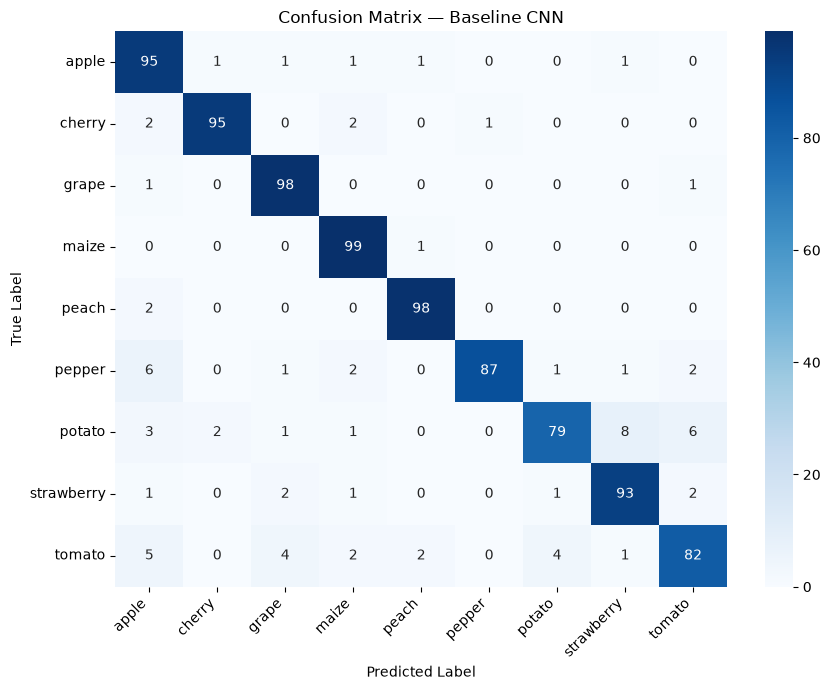

Confusion matrix saved to: /content/eval_results/cnn_confusion_matrix.png

Total misclassified images for Baseline CNN: 74
true_label predicted_label                                                               file_path
     apple          cherry  /content/training_data/test/apple/25308799c6c7417787394d51325229ef.jpg
     apple      strawberry  /content/training_data/test/apple/4629f08ff60d49f6a4734913ef4ba4c6.jpg
     apple           maize  /content/training_data/test/apple/3b633079014b45cb9e1b82029151e033.jpg
     apple           peach  /content/training_data/test/apple/9ea3bb828270437e9ad9f8031fceb6c9.jpg
     apple           grape  /content/training_data/test/apple/945358bb03514eb3a6797a62794638fd.jpg
    cherry           maize /content/training_data/test/cherry/417d01d37d4c44cfad4d8af7894a5241.jpg
    cherry           apple /content/training_data/test/cherry/8bb7899342654e5c81933a688a0d73e9.jpg
    cherry           apple /content/training_data/test/cherry/89425f0b95a34e88a199d9d

In [ ]:
def cnn_predict(filepath):
    image = Image.open(filepath).convert("RGB")
    tensor = cnn_transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = cnn_model(tensor)
        pred_idx = logits.argmax(dim=1).item()
    # Index -> class name must use the full 9-class list (the order the
    # checkpoint's output layer was trained on). This matches EVAL_CLASSES
    # once Section 4b has backfilled every class, but would differ from a
    # shorter EVAL_CLASSES if that backfill step is skipped.
    return MODEL_CLASSES[pred_idx]


cnn_results = evaluate_model("Baseline CNN", cnn_predict, test_samples, EVAL_CLASSES, progress_every=100)
cnn_metrics = compute_and_report_metrics(cnn_results, EVAL_CLASSES, save_prefix="cnn")
cnn_misclassified_df = log_misclassifications(cnn_results, max_rows=30)

## 11. Evaluate SmolVLM (Generative Model)

This step is much slower than the CNN evaluation — each image requires a full
text-generation pass rather than a single forward pass, so evaluating several
hundred images can take a meaningful amount of time on a Colab GPU. Progress
prints every 10 images (elapsed time and an estimated time remaining) so the
cell doesn't look stalled during a long run. If the runtime disconnects partway
through, you'll need to re-run this cell from the start; the CNN results
computed in Section 10 are unaffected as long as the runtime itself isn't
restarted.

Starting evaluation: SmolVLM-256M (LoRA) (900 images)
  [SmolVLM-256M (LoRA)] 10/900 images (1%) — elapsed 13s, est. remaining 1187s
  [SmolVLM-256M (LoRA)] 20/900 images (2%) — elapsed 25s, est. remaining 1109s
  [SmolVLM-256M (LoRA)] 30/900 images (3%) — elapsed 37s, est. remaining 1079s
  [SmolVLM-256M (LoRA)] 40/900 images (4%) — elapsed 49s, est. remaining 1062s
  [SmolVLM-256M (LoRA)] 50/900 images (6%) — elapsed 60s, est. remaining 1025s
  [SmolVLM-256M (LoRA)] 60/900 images (7%) — elapsed 71s, est. remaining 993s
  [SmolVLM-256M (LoRA)] 70/900 images (8%) — elapsed 81s, est. remaining 963s
  [SmolVLM-256M (LoRA)] 80/900 images (9%) — elapsed 102s, est. remaining 1042s
  [SmolVLM-256M (LoRA)] 90/900 images (10%) — elapsed 112s, est. remaining 1011s
  [SmolVLM-256M (LoRA)] 100/900 images (11%) — elapsed 124s, est. remaining 994s
  [SmolVLM-256M (LoRA)] 110/900 images (12%) — elapsed 138s, est. remaining 988s
  [SmolVLM-256M (LoRA)] 120/900 images (13%) — elapsed 150s, est. remain

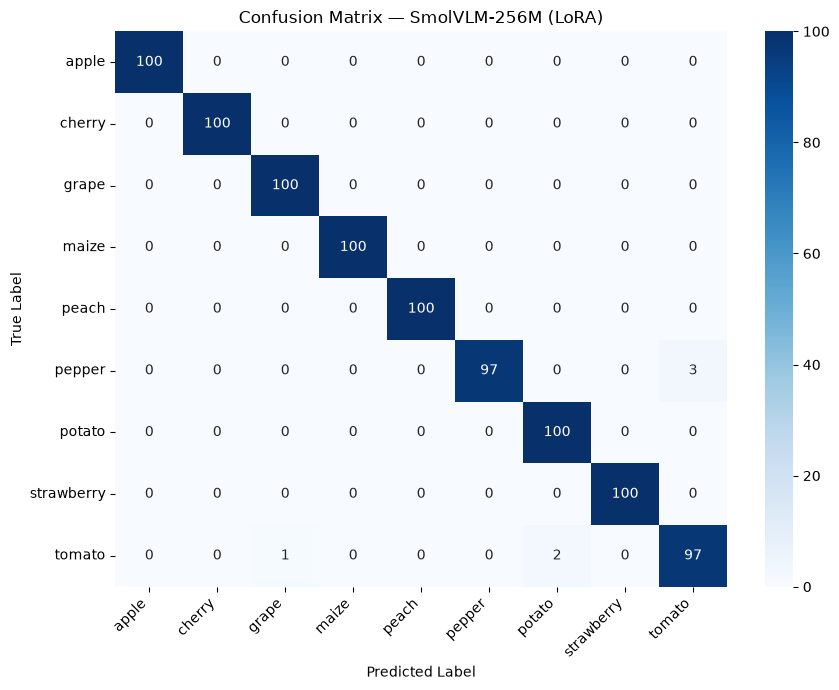

Confusion matrix saved to: /content/eval_results/vlm_confusion_matrix.png

Total misclassified images for SmolVLM-256M (LoRA): 6
true_label predicted_label                                                               file_path
    pepper          tomato /content/training_data/test/pepper/c6a55ac5640f43e1b61bcdbd4342f120.jpg
    pepper          tomato /content/training_data/test/pepper/cfa2f5ba76d44864b7a89ec6a233f83e.jpg
    pepper          tomato /content/training_data/test/pepper/8cb7b2060e8743bab3cbc49ea14d32a8.jpg
    tomato           grape /content/training_data/test/tomato/06c631dca1cb42c39fbf131289a67041.jpg
    tomato          potato /content/training_data/test/tomato/f1c545fa790c45769c1ce37ca8679893.jpg
    tomato          potato /content/training_data/test/tomato/75684cc835834ba6a9802ce3926df1eb.jpg

Full misclassification log saved to: /content/eval_results/smolvlm-256m_(lora)_misclassified.csv


In [ ]:
def vlm_predict(filepath):
    image = Image.open(filepath).convert("RGB")
    generated_text = vlm_generate(image)
    return keyword_match_prediction(generated_text)


vlm_results = evaluate_model("SmolVLM-256M (LoRA)", vlm_predict, test_samples, EVAL_CLASSES, progress_every=10)
vlm_metrics = compute_and_report_metrics(vlm_results, EVAL_CLASSES, save_prefix="vlm")
vlm_misclassified_df = log_misclassifications(vlm_results, max_rows=30)

## 12. Side-by-Side Model Comparison

Model Comparison Summary
                     accuracy  macro_precision  macro_recall  macro_f1  n_samples
model_name                                                                       
Baseline CNN           0.9178           0.9203        0.9178    0.9171        900
SmolVLM-256M (LoRA)    0.9933           0.9934        0.9933    0.9933        900

Comparison table saved to: /content/eval_results/model_comparison_summary.csv


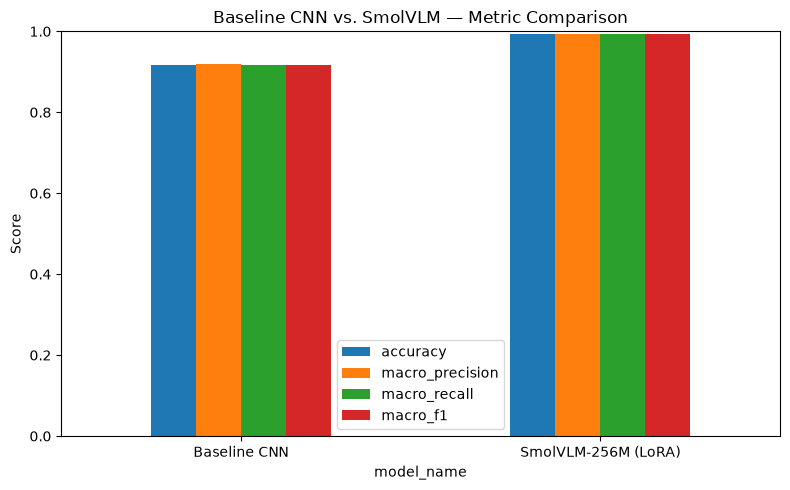

In [ ]:
comparison_df = pd.DataFrame([cnn_metrics, vlm_metrics]).set_index("model_name")
comparison_df = comparison_df[["accuracy", "macro_precision", "macro_recall", "macro_f1", "n_samples"]]

print("Model Comparison Summary")
print(comparison_df.round(4).to_string())

comparison_path = RESULTS_DIR / "model_comparison_summary.csv"
comparison_df.to_csv(comparison_path)
print(f"\nComparison table saved to: {comparison_path}")

ax = comparison_df[["accuracy", "macro_precision", "macro_recall", "macro_f1"]].plot(
    kind="bar", figsize=(8, 5), rot=0
)
ax.set_title("Baseline CNN vs. SmolVLM — Metric Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison_chart.png", dpi=150)
plt.show()

## 13. Notes for the Final Group Report

- `eval_results/` contains: two confusion matrix images, two misclassification CSV logs,
  and a `model_comparison_summary.csv` with all four metrics for both models.
- For the Error Analysis section, cross-reference `*_misclassified.csv` file paths against
  the source images to identify recurring failure patterns (e.g. visually similar diseases,
  poor lighting, or classes the VLM's keyword heuristic under-detects).
- **Methodology note worth stating explicitly in the report:** evaluation covers 5 of
  the CNN's 9 trained classes (`cherry`, `peach`, `pepper`, `strawberry` were excluded
  due to insufficient test data). If the CNN ever predicts one of the excluded classes
  for a test image, it still shows up as a misclassification and as an extra column in
  the confusion matrix — it is not silently discarded.
- If GPU memory is limited, restart the runtime between the CNN and SmolVLM sections
  (`Runtime > Restart session`) and re-run only the required cells.
